In [1]:
#imports
from sklearn.datasets import fetch_openml
import numpy as np
from brian2 import *
from tqdm import tqdm
import os
import gc

prefs.codegen.target = 'cython'
# prefs.codegen.target = 'numpy'

from constants import *
from equations import *
from network import *

In [2]:
#download mnist data
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist.data.to_numpy(), mnist.target.to_numpy()

In [3]:
#spliting into train and test sets
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 784) (60000,)
(10000, 784) (10000,)


In [4]:
# a simple training loop, which trains the model one image at a time.
# this is too slow, so I'll be using a different method.

# presentation_time = 350 * ms #350
# resting_time = 150 * ms #150
# num_examples = 1000

# for i in tqdm(range(num_examples), desc="Processing"):   
#     # Rate Encoding
#     image_pixels = X_train[i]
#     firing_rates = (image_pixels / 4.0) * Hz
    
#     # Presentation Phase 
#     inp_group.rates = firing_rates
#     net.run(presentation_time)
    
#     # Resting Phase
#     inp_group.rates = 0 * Hz
#     net.run(resting_time)

In [5]:
# # This speeds up training by pre-packaging all images into a single timeline,
# # This will eliminate the need for a slow python 'for loop'.
# # But this takes too much RAM for 60000 images

# num_examples = 10000  # size of training set
# time_per_block = 50*ms
# blocks_per_image = 7  # 7 blocks = 350ms presentation
# blocks_per_rest = 3   # 3 blocks = 150ms resting
# total_blocks = blocks_per_image + blocks_per_rest  # 7 blocks total (500ms)

# rates_array = np.zeros((num_examples * total_blocks, n_input))

# for idx in tqdm(range(num_examples)):
#     img_rates = X_train[idx] / 4.0 # Rate Encoding
#     start_idx = idx * total_blocks
#     rates_array[start_idx : start_idx + blocks_per_image, :] = img_rates
    
# input_rates = TimedArray(rates_array * Hz, dt=time_per_block)

# # Pass the TimedArray into the network
# net, spike_monitor, inp_group = build_network_train(input_rates)

# # start training
# net.run(num_examples * time_per_img, report='text', report_period=120*second)

In [6]:
num_examples = 60000
batch_size = 6000
num_batches = num_examples // batch_size

time_per_block = 50 * ms
blocks_per_image = 7  # 350ms presentation
blocks_per_rest = 3   # 150ms rest
total_blocks = blocks_per_image + blocks_per_rest  # 10 blocks (500ms) total
batch_duration = batch_size * total_blocks * time_per_block

net, spike_monitor, inp_group = build_network_train()

Network built successfully!


In [7]:
print(f"Start training: {num_batches} batches of {batch_size} images.")

for batch_idx in range(num_batches):
    print(f"\n--- Batch {batch_idx + 1} / {num_batches} ---")

    batch_start_time = batch_idx * batch_duration
    
    # Slice the dataset for this specific batch
    start_img = batch_idx * batch_size
    end_img = start_img + batch_size
    X_batch = X_train[start_img : end_img]
    
    # Create the smaller rates array
    rates_array = np.zeros((batch_size * total_blocks, n_input), dtype=np.float32)

    for idx in range(batch_size):
        img_rates = X_batch[idx] / 4.0 
        start_idx_arr = idx * total_blocks
        rates_array[start_idx_arr : start_idx_arr + blocks_per_image, :] = img_rates
        
    # Create the TimedArray for this batch
    input_rates = TimedArray(rates_array * Hz, dt=time_per_block)
    
    # Run the network
    net.run(batch_size * total_blocks * time_per_block, report='text', report_period=600*second)
    
    del rates_array
    del input_rates
    gc.collect()

print("\nTraining Complete")

Start training: 10 batches of 6000 images.

--- Batch 1 / 10 ---
Starting simulation at t=0. s for a duration of 3. ks
0.5259588 ks (17%) simulated in 10m 0s, estimated 47m 2s remaining.
1.0109725 ks (33%) simulated in 20m 0s, estimated 39m 21s remaining.
1.4785971 ks (49%) simulated in 30m 0s, estimated 30m 52s remaining.
1.9293058 ks (64%) simulated in 40m 0s, estimated 22m 12s remaining.
2.3652791 ks (78%) simulated in 50m 0s, estimated 13m 25s remaining.
2.7829344 ks (92%) simulated in 1h 0m 0s, estimated 4m 41s remaining.
3. ks (100%) simulated in 1h 5m 16s

--- Batch 2 / 10 ---
Starting simulation at t=3. ks for a duration of 3. ks
0.4019374 ks (13%) simulated in 10m 0s, estimated 1h 4m 38s remaining.
0.7969105 ks (26%) simulated in 20m 0s, estimated 55m 17s remaining.
1.181326 ks (39%) simulated in 30m 0s, estimated 46m 11s remaining.
1.5567524 ks (51%) simulated in 40m 0s, estimated 37m 5s remaining.
1.9326381 ks (64%) simulated in 50m 0s, estimated 27m 37s remaining.
2.3066789

In [8]:
# saving the trained model weights

save_path = './trained_model/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

trained_weights = np.array(net['s_inp_exc'].w)
np.save(os.path.join(save_path, 'weights.npy'), trained_weights)

trained_theta = np.array(net['exc'].theta)
np.save(os.path.join(save_path, 'thetas.npy'), trained_theta)

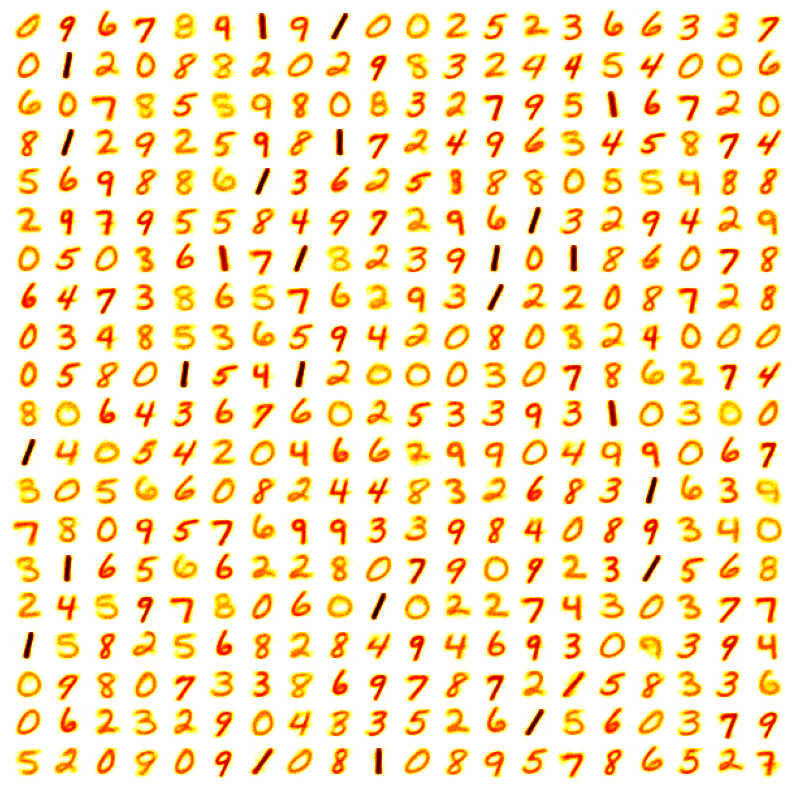

In [9]:
# plotting the receptive field

def get_2d_weights(synapse_group, n_input, n_e):
    """extracts weights into a 2D matrix"""
    weight_matrix = np.zeros((n_input, n_e))
    weight_matrix[synapse_group.i, synapse_group.j] = synapse_group.w
    return weight_matrix

def plot_weights(weights, n_e):
    """Plots the weights as a grid of 28x28 images."""
    fig, axes = plt.subplots(int(np.sqrt(n_e)), int(np.sqrt(n_e)), figsize=(10, 10))
    wmax = np.max(weights) 
    for i, ax in enumerate(axes.flat):
        ax.imshow(weights[:, i].reshape(28, 28), cmap='hot_r', vmin=0, vmax=wmax)
        ax.axis('off')
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    plt.show()
    
final_weights = get_2d_weights(net['s_inp_exc'], n_input, n_e)
plot_weights(final_weights, n_e)